
**Pipelines couverts :**
1. **Pipeline NLP** — Prétraitement → BoW → TF-IDF → Word2Vec → FastText (→ CamemBERT optionnel)
2. **Pipeline ML Numérique** — Features numériques + tuning hyperparamètres
3. **Pipeline Multimodal** — Fusion `hstack` sparse + `ColumnTransformer` sklearn + Stacking


## 0. Imports & Configuration Globale

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack, csr_matrix

# ── Embeddings ────────────────────────────────────────────────────────────────
from gensim.models import Word2Vec, FastText

# ── MLflow ────────────────────────────────────────────────────────────────────
import mlflow
import mlflow.sklearn

# ── Style global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.figsize': (10, 5)
})

RANDOM_STATE = 42
print("✅ Imports OK")

✅ Imports OK


## 📂 1. Chargement des Données

In [2]:
df_clean = pd.read_csv("../data/df_clean.csv")

text_col  = "Rapport_Collecte"
target    = "Categorie"

# ── Colonnes numériques (adapter selon le dataset réel) ───────────────────────
# On détecte automatiquement les colonnes numériques hors texte & cible
num_cols = [
    c for c in df_clean.select_dtypes(include=[np.number]).columns
    if c not in [target]
]

print(f"📊 Dimensions : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")
print(f"📝 Colonne texte : {text_col}")
print(f"🔢 Colonnes numériques ({len(num_cols)}) : {num_cols}")
print(f"\n🏷️  Distribution des catégories :")
print(df_clean[target].value_counts())
print(f"\n📄 Exemple de rapport brut :")
print(df_clean[text_col].iloc[0])

X_text = df_clean[text_col].astype(str)
X_num  = df_clean[num_cols].copy()
y      = df_clean[target]

📊 Dimensions : 9724 lignes × 9 colonnes
📝 Colonne texte : Rapport_Collecte
🔢 Colonnes numériques (7) : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Source']

🏷️  Distribution des catégories :
Categorie
2    2731
3    2496
0    2285
1    2212
Name: count, dtype: int64

📄 Exemple de rapport brut :
Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau souple, non conducteur, aspect très opaque. Bon état général.


### 1.1 Analyse Exploratoire — Texte & Numérique

=== STATISTIQUES TEXTES ===
       rapport_len  rapport_words
count       9724.0         9724.0
mean         145.8           21.0
std           16.4            2.4
min           98.0           15.0
25%          135.0           19.0
50%          146.0           21.0
75%          158.0           23.0
max          189.0           28.0


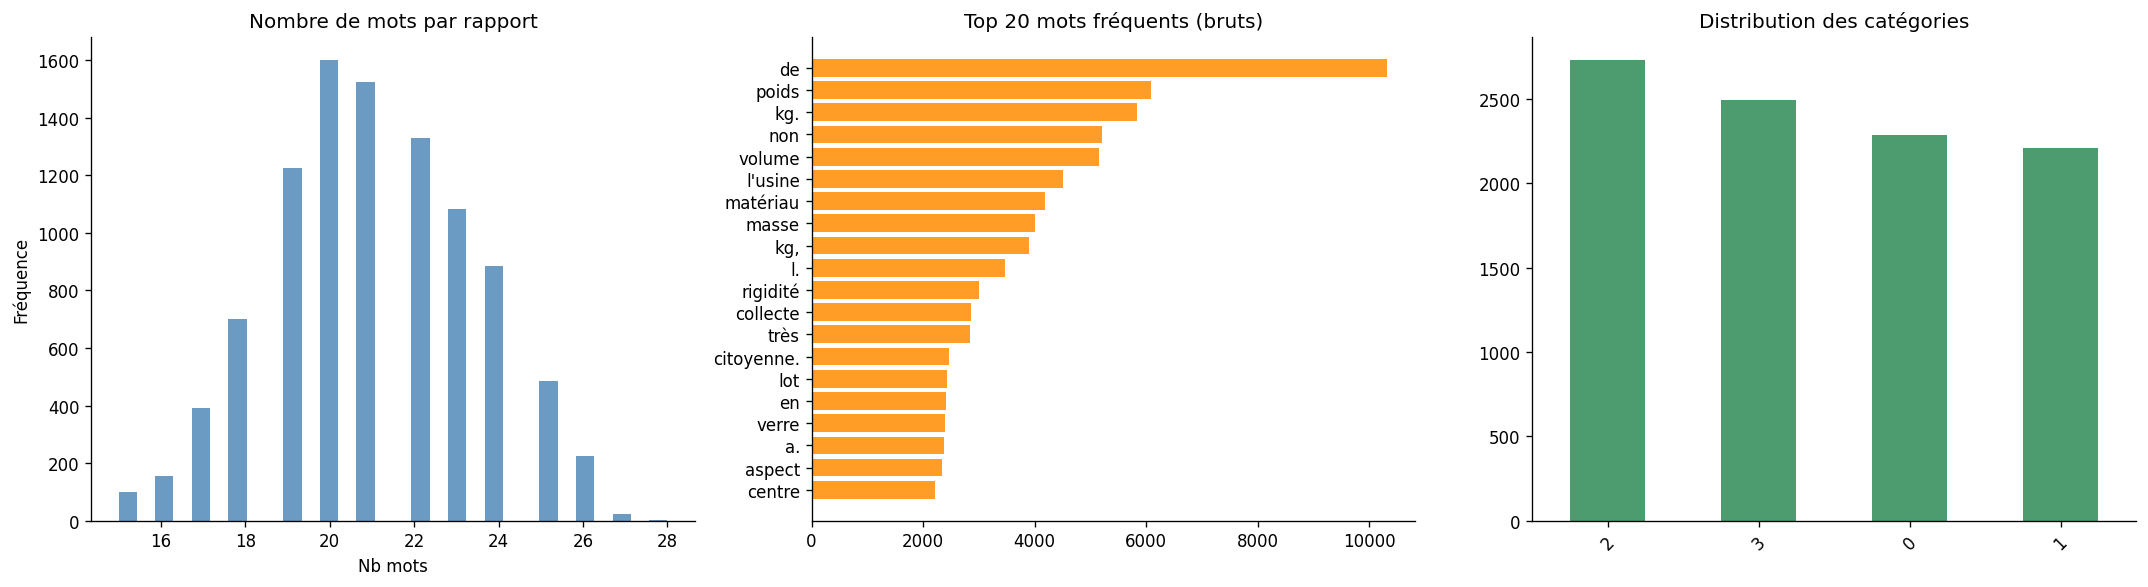


=== STATISTIQUES NUMÉRIQUES ===
         Poids   Volume  Conductivite  Opacite  Rigidite  Prix_Revente  \
count  9724.00  9724.00       9724.00  9724.00   9724.00       9724.00   
mean     73.54   145.70          0.21     0.60      5.93          5.70   
std      69.75   134.34          0.38     0.39      3.08          5.04   
min       1.98     0.47          0.00     0.00      1.00          0.10   
25%      20.83    46.13          0.00     0.20      3.00          1.60   
50%      40.08    88.51          0.00     0.54      5.00          4.21   
75%     129.46   236.61          0.00     1.00      9.00          6.86   
max     292.40   522.34          1.00     1.00     10.00         14.75   

        Source  
count  9724.00  
mean      1.47  
std       1.07  
min       0.00  
25%       1.00  
50%       1.00  
75%       2.00  
max       3.00  

Valeurs manquantes : {'Poids': 0, 'Volume': 0, 'Conductivite': 0, 'Opacite': 0, 'Rigidite': 0, 'Prix_Revente': 0, 'Source': 0}


In [3]:
# ── Statistiques textuelles ───────────────────────────────────────────────────
df_clean['rapport_len']   = df_clean[text_col].apply(len)
df_clean['rapport_words'] = df_clean[text_col].apply(lambda x: len(x.split()))

print("=== STATISTIQUES TEXTES ===")
print(df_clean[['rapport_len', 'rapport_words']].describe().round(1))

# ── Top mots (bruts) ─────────────────────────────────────────────────────────
all_words = ' '.join(df_clean[text_col]).lower().split()
freq      = Counter(all_words).most_common(20)
words, counts = zip(*freq)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramme longueurs
axes[0].hist(df_clean['rapport_words'], bins=30, color='steelblue', alpha=0.8)
axes[0].set_title("Nombre de mots par rapport")
axes[0].set_xlabel("Nb mots")
axes[0].set_ylabel("Fréquence")

# Top mots
axes[1].barh(words[::-1], counts[::-1], color='darkorange', alpha=0.85)
axes[1].set_title("Top 20 mots fréquents (bruts)")

# Distribution cible
y.value_counts().plot(kind='bar', ax=axes[2], color='seagreen', alpha=0.85)
axes[2].set_title("Distribution des catégories")
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── Statistiques numériques ───────────────────────────────────────────────────
if num_cols:
    print("\n=== STATISTIQUES NUMÉRIQUES ===")
    print(X_num.describe().round(2))
    print(f"\nValeurs manquantes : {X_num.isnull().sum().to_dict()}")

---
##  Partie 1 — Pipeline NLP
### 2. Prétraitement Textuel

In [4]:
# ── Stopwords ─────────────────────────────────────────────────────────────────
STOPWORDS_FR = set(stopwords.words("french"))

STOPWORDS_DOMAINE = {
    # administratif
    "rapport", "collecte", "observation", "note", "constat",
    "visite", "lot", "provenance", "provenant", "issu", "origine",
    # lieux
    "site", "zone", "secteur", "centre", "usine", "municipal",
    "localisation", "emplacement",
    # organisation
    "agent", "équipe", "general", "général",
    # qualité générique
    "standard", "standards", "conforme",
    "verification", "vérification", "recommandee", "recommandée",
    "prioritaire",
    # mesures déjà couvertes par features numériques
    "poids", "volume", "masse", "kg", "l",
    "mesuré", "mesure", "estimé", "estime",
    # intensité inutile
    "très", "extremement", "extrêmement",
    "moyen", "moyenne", "faible", "élevée",
    # mots vides dataset
    "non", "aucune", "aucun", "sans"
}

STOPWORDS_TOUS = STOPWORDS_FR | STOPWORDS_DOMAINE
stemmer = FrenchStemmer()


def preprocess(text: str) -> str:
    """
    Pipeline NLP EcoSmart :
    1. Mise en minuscules
    2. Suppression des caractères non-alphabétiques (garde accents français)
    3. Tokenisation par split
    4. Suppression des stopwords FR + domaine
    5. Suppression des tokens ≤ 2 caractères
    6. Stemming via FrenchStemmer (NLTK Snowball)

    NB : les chiffres sont extraits AVANT ce pipeline sur le texte brut
    pour constituer les features numériques (Section Pipeline Numérique).
    """
    text = text.lower()
    text = re.sub(r"[^a-zàâäéèêëîïôùûüç\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS_TOUS and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)


# ── Démonstration ─────────────────────────────────────────────────────────────
exemple_brut = X_text.iloc[0]
print("📋 AVANT nettoyage :")
print(f"  {exemple_brut[:250]}...")
print(f"\n✅ APRÈS nettoyage :")
print(f"  {preprocess(exemple_brut)[:250]}...")
print(f"\n📌 Transformations appliquées :")
print("  • Minuscules        → réduction de la dispersion lexicale")
print("  • Ponctuation       → suppression du bruit non-sémantique")
print("  • Stop-words custom → conservation des termes porteurs de sens métier")
print("  • Stemming          → 'collecté/collectés/collectée' → 'collect'")

📋 AVANT nettoyage :
  Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau souple, non conducteur, aspect très opaque. Bon état général....

✅ APRÈS nettoyage :
  papi récuper renseign leg matériau soupl conducteur aspect opaqu bon état...

📌 Transformations appliquées :
  • Minuscules        → réduction de la dispersion lexicale
  • Ponctuation       → suppression du bruit non-sémantique
  • Stop-words custom → conservation des termes porteurs de sens métier
  • Stemming          → 'collecté/collectés/collectée' → 'collect'


### 3. Split Train / Validation / Test

In [5]:
# ── Split 70/15/15 stratifié ──────────────────────────────────────────────────
(
    X_text_train, X_text_tmp,
    X_num_train,  X_num_tmp,
    y_train,      y_tmp
) = train_test_split(
    X_text, X_num, y,
    test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

(
    X_text_val, X_text_test,
    X_num_val,  X_num_test,
    y_val,      y_test
) = train_test_split(
    X_text_tmp, X_num_tmp, y_tmp,
    test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp
)

print("=== SPLITS ===")
print(f"Train : {len(X_text_train)} ({len(X_text_train)/len(y)*100:.0f}%)")
print(f"Val   : {len(X_text_val)}  ({len(X_text_val)/len(y)*100:.0f}%)")
print(f"Test  : {len(X_text_test)}  ({len(X_text_test)/len(y)*100:.0f}%)")

# ── Prétraitement texte ───────────────────────────────────────────────────────
X_train_clean = X_text_train.apply(preprocess)
X_val_clean   = X_text_val.apply(preprocess)
X_test_clean  = X_text_test.apply(preprocess)

vocab = set(" ".join(X_train_clean).split())
print(f"\n📖 Vocabulaire entraînement : {len(vocab)} tokens")

=== SPLITS ===
Train : 6806 (70%)
Val   : 1459  (15%)
Test  : 1459  (15%)

📖 Vocabulaire entraînement : 116 tokens


### 4. Configuration des Modèles & MLflow

In [6]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
exp = mlflow.set_experiment("EcoSmart_Classification")
print("📊 MLflow experiment initialisé")

# ── Modèles pour représentations sparse (BoW / TF-IDF) ────────────────────────
def get_models_text():
    return {
        "Naive Bayes":        MultinomialNB(),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Linear SVC":          LinearSVC(random_state=RANDOM_STATE),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    }

# ── Modèles pour embeddings denses (Word2Vec, FastText) ───────────────────────
def get_models_emb():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Linear SVC":          LinearSVC(random_state=RANDOM_STATE),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    }


def evaluate(model, Xtr, Xte, ytr, yte,
             representation="unknown", model_name="unknown", log_mlflow=True):
    """Entraîne, évalue et logue les métriques dans MLflow."""
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    acc  = accuracy_score(yte, pred)
    prec = precision_score(yte, pred, average="weighted", zero_division=0)
    rec  = recall_score(yte, pred, average="weighted", zero_division=0)
    f1   = f1_score(yte, pred, average="weighted", zero_division=0)

    if log_mlflow:
        with mlflow.start_run(
            experiment_id=exp.experiment_id,
            run_name=f"{representation}_{model_name}"
        ):
            mlflow.set_tags({
                "representation": representation,
                "model_name":     model_name,
                "dataset":        "EcoSmart",
                "task":           "text_classification"
            })
            mlflow.log_metrics({
                "accuracy":  acc,
                "precision": prec,
                "recall":    rec,
                "f1":        f1
            })

    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}


def plot_confusion(model, X_test_rep, y_test, title=""):
    """Affiche la matrice de confusion + classification report."""
    y_pred = model.predict(X_test_rep)
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Matrice normalisée
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), ax=axes[0])
    axes[0].set_title(f"Matrice normalisée — {title}")
    axes[0].set_xlabel("Prédit")
    axes[0].set_ylabel("Réel")

    # Matrice brute
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), ax=axes[1])
    axes[1].set_title(f"Matrice brute — {title}")
    axes[1].set_xlabel("Prédit")
    axes[1].set_ylabel("Réel")

    plt.tight_layout()
    plt.show()
    print(f"\n=== Classification Report — {title} ===")
    print(classification_report(y_test, y_pred, zero_division=0))


print("✅ Fonctions utilitaires chargées")

📊 MLflow experiment initialisé
✅ Fonctions utilitaires chargées


---
### 4.1 Bag of Words — Baseline


=== BAG OF WORDS ===

── Naive Bayes ──
   Accuracy    : 0.9650
   Precision   : 0.9666
   Recall      : 0.9650
   F1-score    : 0.9653

── Logistic Regression ──
   Accuracy    : 0.9623
   Precision   : 0.9635
   Recall      : 0.9623
   F1-score    : 0.9625

── Linear SVC ──
   Accuracy    : 0.9623
   Precision   : 0.9635
   Recall      : 0.9623
   F1-score    : 0.9625

── Random Forest ──
   Accuracy    : 0.9644
   Precision   : 0.9647
   Recall      : 0.9644
   F1-score    : 0.9644

🏆 Meilleur modèle BoW : Naive Bayes (F1=0.9653)


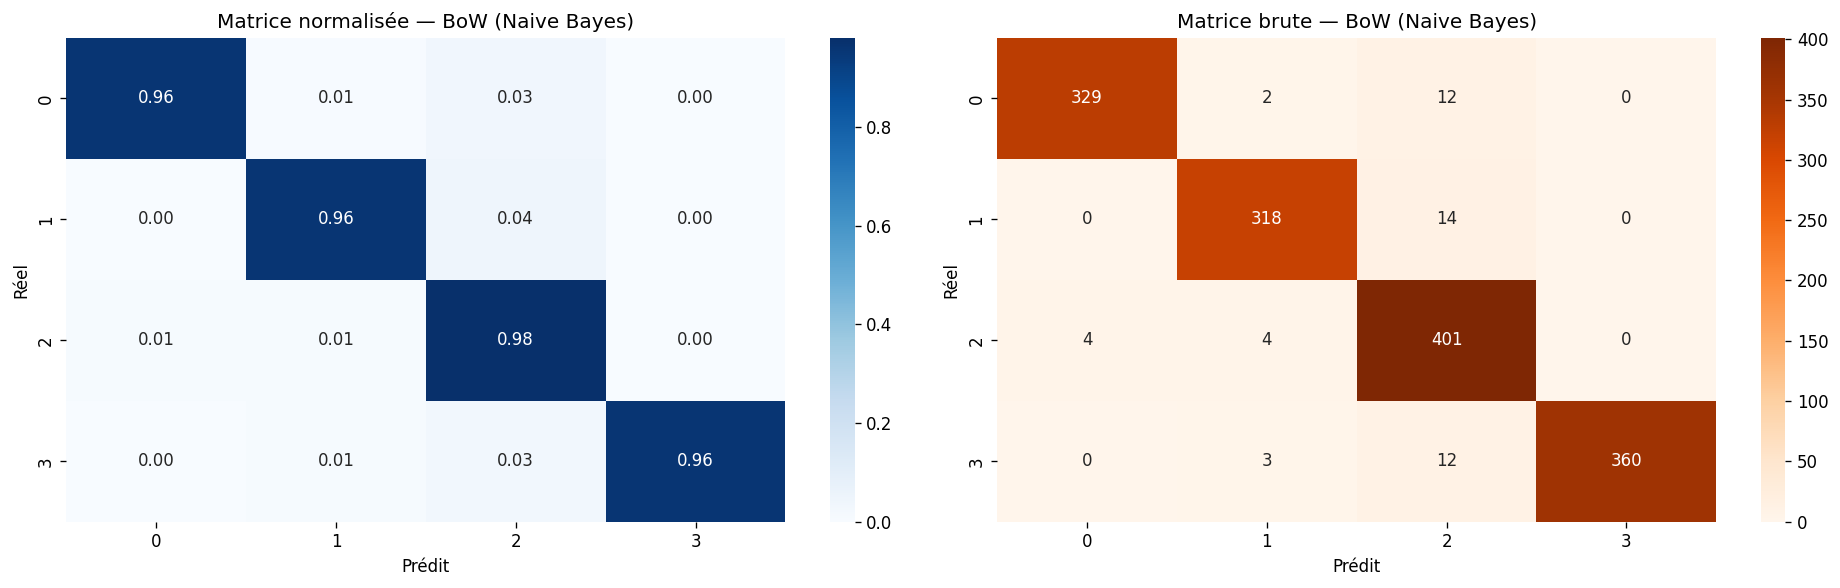


=== Classification Report — BoW (Naive Bayes) ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       343
           1       0.97      0.96      0.97       332
           2       0.91      0.98      0.95       409
           3       1.00      0.96      0.98       375

    accuracy                           0.97      1459
   macro avg       0.97      0.96      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [7]:
print("\n=== BAG OF WORDS ===")

bow = CountVectorizer(max_features=500)
X_train_bow = bow.fit_transform(X_train_clean)
X_val_bow   = bow.transform(X_val_clean)
X_test_bow  = bow.transform(X_test_clean)

results_bow = {}
for name, model in get_models_text().items():
    metrics = evaluate(model, X_train_bow, X_test_bow, y_train, y_test,
                       representation="BoW", model_name=name)
    results_bow[name] = metrics
    print(f"\n── {name} ──")
    for k, v in metrics.items():
        print(f"   {k:12s}: {v:.4f}")

# ── Matrice de confusion — meilleur BoW ───────────────────────────────────────
best_bow = max(results_bow, key=lambda x: results_bow[x]["F1-score"])
print(f"\n🏆 Meilleur modèle BoW : {best_bow} (F1={results_bow[best_bow]['F1-score']:.4f})")

best_bow_model = get_models_text()[best_bow]
best_bow_model.fit(X_train_bow, y_train)
plot_confusion(best_bow_model, X_test_bow, y_test, title=f"BoW ({best_bow})")

### 4.2 TF-IDF avec N-grammes

> **Paramètres clés :**
> - `ngram_range=(1,2)` : capture des concepts comme **"haute conductivité"**, **"légèrement translucide"**
> - `max_features=500` : limitation pour éviter le surapprentissage sur un corpus spécialisé
> - `sublinear_tf=True` : atténue l'effet des mots très fréquents (log(tf))


=== TF-IDF ===

── Naive Bayes ──
   Accuracy    : 0.9650
   Precision   : 0.9660
   Recall      : 0.9650
   F1-score    : 0.9652

── Logistic Regression ──
   Accuracy    : 0.9630
   Precision   : 0.9656
   Recall      : 0.9630
   F1-score    : 0.9634

── Linear SVC ──
   Accuracy    : 0.9630
   Precision   : 0.9637
   Recall      : 0.9630
   F1-score    : 0.9631

── Random Forest ──
   Accuracy    : 0.9650
   Precision   : 0.9654
   Recall      : 0.9650
   F1-score    : 0.9651

🏆 Meilleur modèle : Naive Bayes (F1=0.9652)


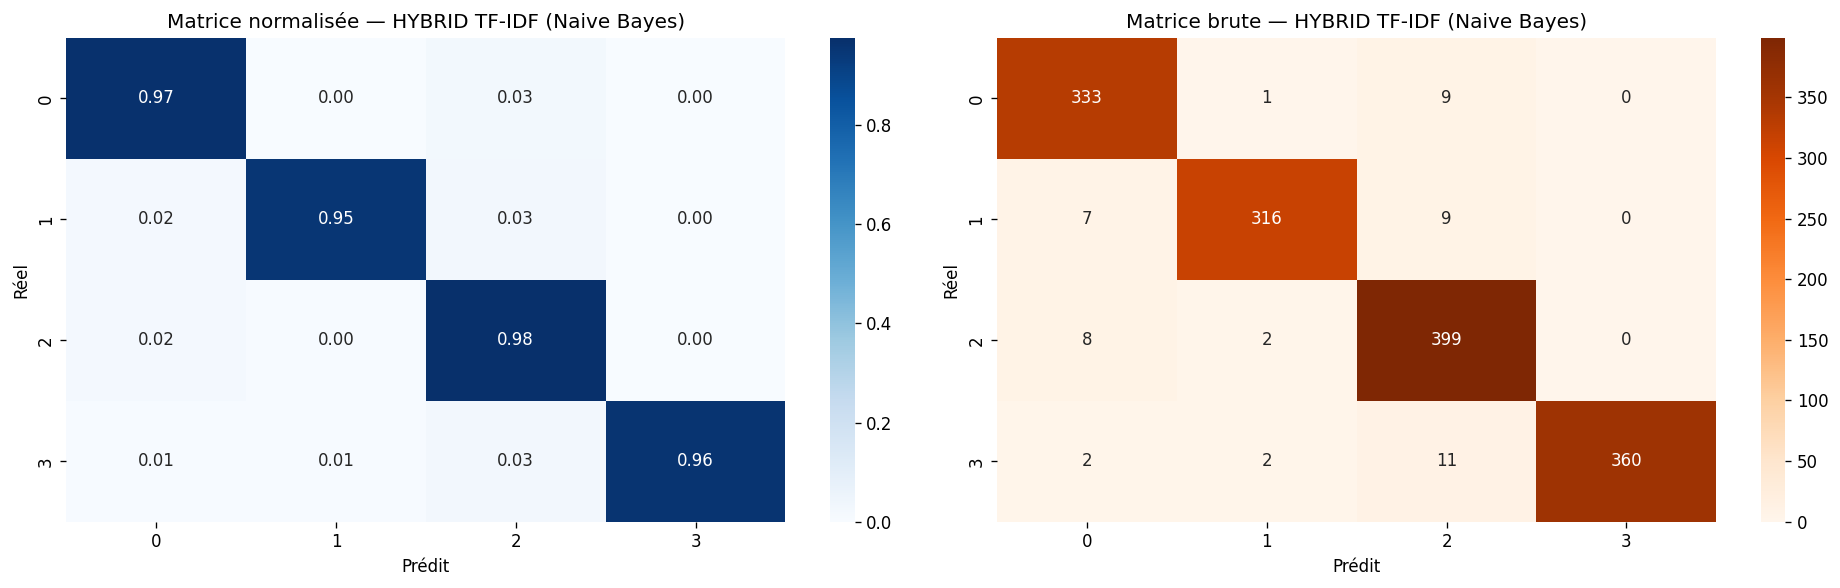


=== Classification Report — HYBRID TF-IDF (Naive Bayes) ===
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       343
           1       0.98      0.95      0.97       332
           2       0.93      0.98      0.95       409
           3       1.00      0.96      0.98       375

    accuracy                           0.97      1459
   macro avg       0.97      0.96      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [8]:
print("\n=== TF-IDF ===")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

# ── WORD TF-IDF ─────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,   # 
    min_df=2,
    sublinear_tf=True
)

# ── CHAR TF-IDF (ROBUSTE AUX FAUTES) ───────
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=3000
)

# ── COMBINAISON ROBUSTE ─────────────────────
vectorizer = FeatureUnion([
    ("word", tfidf),
    ("char", char_tfidf)
])

# ── TRANSFORM ───────────────────────────────
X_train_tfidf = vectorizer.fit_transform(X_train_clean)
X_val_tfidf   = vectorizer.transform(X_val_clean)
X_test_tfidf  = vectorizer.transform(X_test_clean)

# ── TRAIN MODELS ────────────────────────────
results_tfidf = {}

for name, model in get_models_text().items():

    metrics = evaluate(
        model,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test,
        representation="HYBRID (word+char)",
        model_name=name
    )

    results_tfidf[name] = metrics

    print(f"\n── {name} ──")
    for k, v in metrics.items():
        print(f"   {k:12s}: {v:.4f}")

# ── BEST MODEL ──────────────────────────────
best_tfidf = max(results_tfidf, key=lambda x: results_tfidf[x]["F1-score"])

print(f"\n🏆 Meilleur modèle : {best_tfidf} "
      f"(F1={results_tfidf[best_tfidf]['F1-score']:.4f})")

best_tfidf_model = get_models_text()[best_tfidf]
best_tfidf_model.fit(X_train_tfidf, y_train)

plot_confusion(
    best_tfidf_model,
    X_test_tfidf,
    y_test,
    title=f"HYBRID TF-IDF ({best_tfidf})"
)

### 4.3 Comparaison TF-IDF vs BoW

> **Analyse comparative :** TF-IDF atténue les mots très fréquents (peu informatifs) et valorise les termes discriminants. Le support des bigrammes permet de capturer des collocs métier non détectables avec BoW.

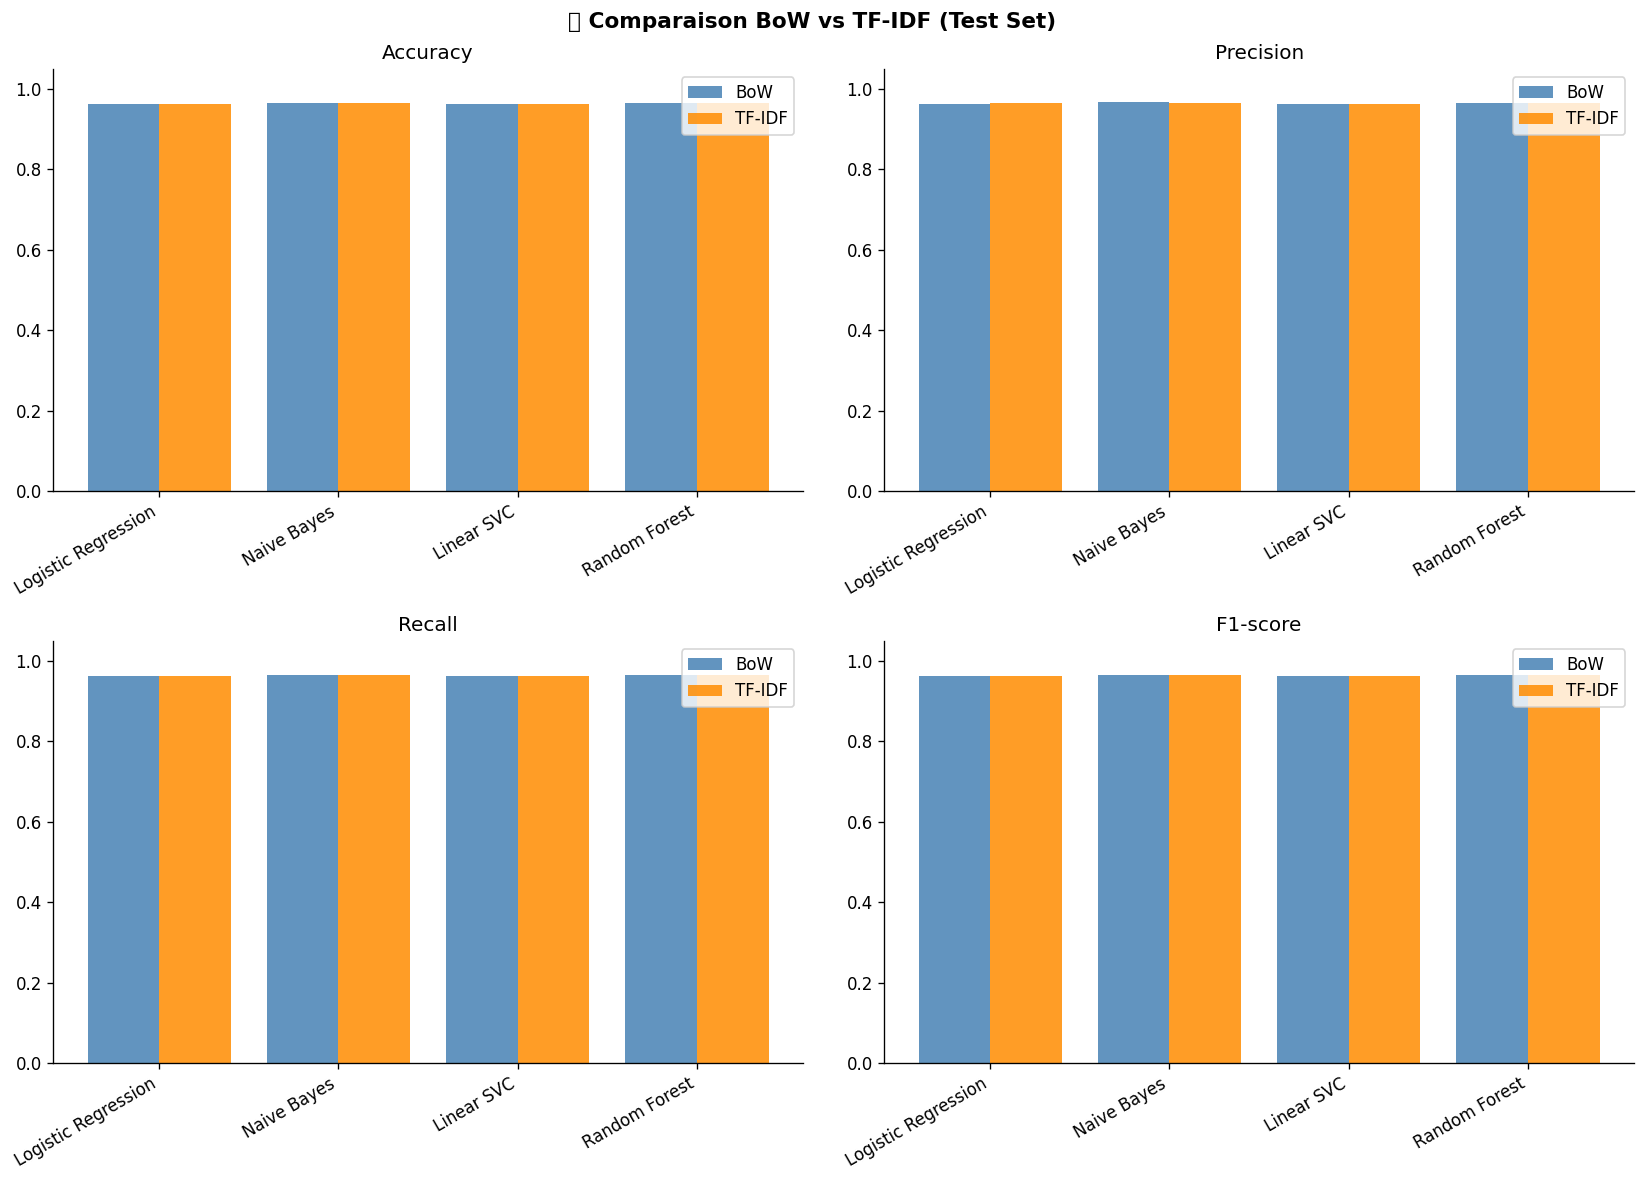


📌 Analyse :
  Logistic Regression      : ΔF1 TF-IDF vs BoW = ↑ 0.0010
  Naive Bayes              : ΔF1 TF-IDF vs BoW = ↓ 0.0001
  Linear SVC               : ΔF1 TF-IDF vs BoW = ↑ 0.0006
  Random Forest            : ΔF1 TF-IDF vs BoW = ↑ 0.0007


In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    models_common = set(results_bow.keys()) & set(results_tfidf.keys())
    x  = list(models_common)
    v1 = [results_bow[m][metric]   for m in x]
    v2 = [results_tfidf[m][metric] for m in x]

    xpos = np.arange(len(x))
    axes[i].bar(xpos - 0.2, v1, 0.4, label='BoW',    color='steelblue', alpha=0.85)
    axes[i].bar(xpos + 0.2, v2, 0.4, label='TF-IDF', color='darkorange', alpha=0.85)
    axes[i].set_title(metric)
    axes[i].set_xticks(xpos)
    axes[i].set_xticklabels(x, rotation=30, ha='right')
    axes[i].set_ylim(0, 1.05)
    axes[i].legend()

plt.suptitle("📊 Comparaison BoW vs TF-IDF (Test Set)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Analyse :")
for m in set(results_bow.keys()) & set(results_tfidf.keys()):
    delta = results_tfidf[m]['F1-score'] - results_bow[m]['F1-score']
    sign  = '↑' if delta > 0 else '↓'
    print(f"  {m:25s}: ΔF1 TF-IDF vs BoW = {sign} {abs(delta):.4f}")

---
### 5. Plongements Lexicaux (Embeddings)

### 5.1 Word2Vec

> **Principe :** Word2Vec (skip-gram/CBOW) apprend des représentations vectorielles en exploitant le **contexte d'apparition**.
> "métal" et "conductivité" co-occurrant fréquemment → cosinus de similarité élevé → vecteur moyenné pertinent pour la classification.


=== WORD2VEC ===
Vocabulaire Word2Vec : 116 tokens

── Logistic Regression ──
   Accuracy    : 0.9637
   Precision   : 0.9651
   Recall      : 0.9637
   F1-score    : 0.9639

── Linear SVC ──
   Accuracy    : 0.9630
   Precision   : 0.9653
   Recall      : 0.9630
   F1-score    : 0.9634

── Random Forest ──
   Accuracy    : 0.9664
   Precision   : 0.9668
   Recall      : 0.9664
   F1-score    : 0.9665

🏆 Meilleur modèle Word2Vec : Random Forest (F1=0.9665)


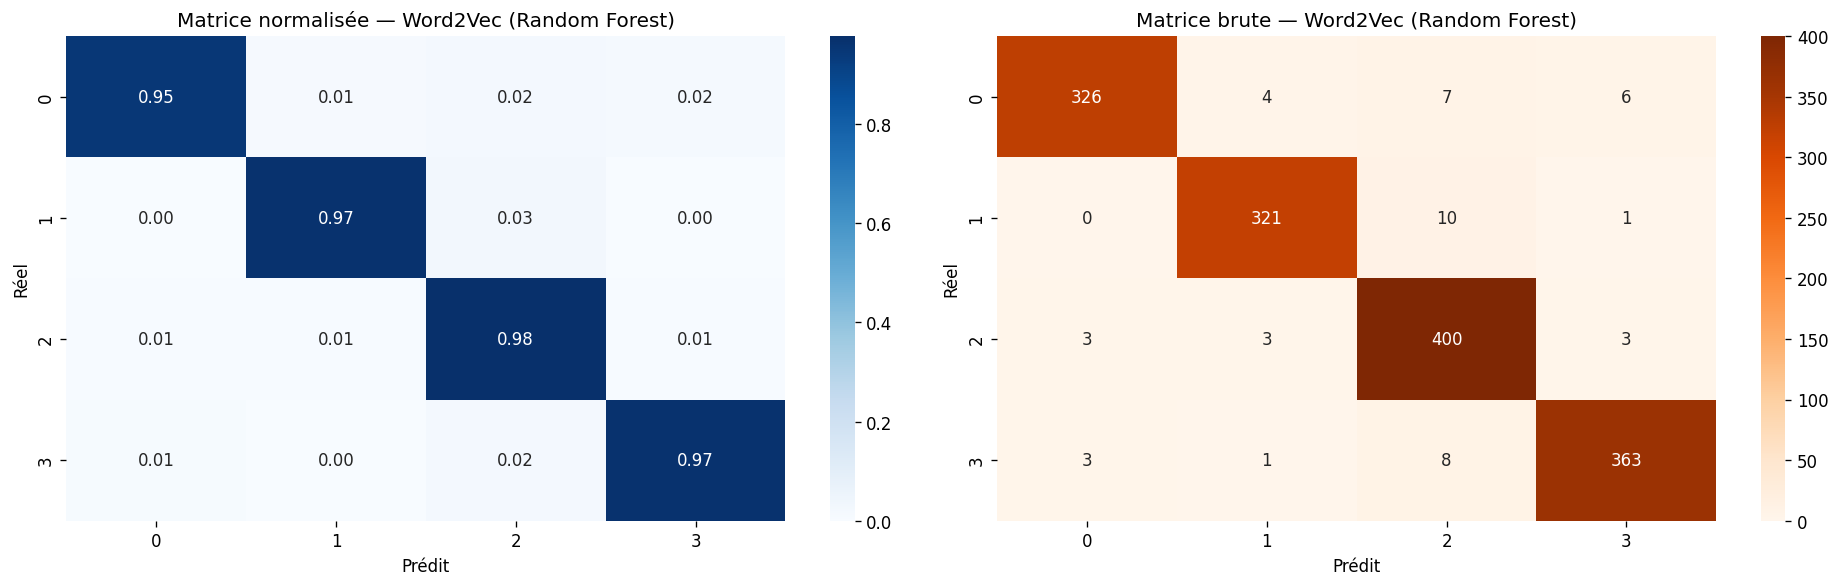


=== Classification Report — Word2Vec (Random Forest) ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       343
           1       0.98      0.97      0.97       332
           2       0.94      0.98      0.96       409
           3       0.97      0.97      0.97       375

    accuracy                           0.97      1459
   macro avg       0.97      0.97      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [10]:
print("\n=== WORD2VEC ===")

sentences_train = [text.split() for text in X_train_clean]

w2v = Word2Vec(sentences_train, vector_size=100, window=5,
               min_count=2, workers=4, seed=RANDOM_STATE)
print(f"Vocabulaire Word2Vec : {len(w2v.wv)} tokens")


def vectorize_w2v(text, model=w2v, size=100):
    words = text.split()
    vecs  = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)


X_train_w2v = np.array([vectorize_w2v(t) for t in X_train_clean])
X_val_w2v   = np.array([vectorize_w2v(t) for t in X_val_clean])
X_test_w2v  = np.array([vectorize_w2v(t) for t in X_test_clean])

results_w2v = {}
for name, model in get_models_emb().items():
    metrics = evaluate(model, X_train_w2v, X_test_w2v, y_train, y_test,
                       representation="Word2Vec", model_name=name)
    results_w2v[name] = metrics
    print(f"\n── {name} ──")
    for k, v in metrics.items():
        print(f"   {k:12s}: {v:.4f}")

# ── Matrice de confusion — meilleur W2V ───────────────────────────────────────
best_w2v = max(results_w2v, key=lambda x: results_w2v[x]["F1-score"])
print(f"\n🏆 Meilleur modèle Word2Vec : {best_w2v} (F1={results_w2v[best_w2v]['F1-score']:.4f})")

best_w2v_model = get_models_emb()[best_w2v]
best_w2v_model.fit(X_train_w2v, y_train)
plot_confusion(best_w2v_model, X_test_w2v, y_test, title=f"Word2Vec ({best_w2v})")

### 5.2 FastText

> **Avantage clé vs Word2Vec :** FastText représente les mots via leurs **sous-mots** (n-grammes de caractères). Cela lui permet de gérer les mots hors-vocabulaire (OOV) — particulièrement utile sur des corpus techniques avec des formes fléchies rares.


=== FASTTEXT ===

── Logistic Regression ──
   Accuracy    : 0.9589
   Precision   : 0.9593
   Recall      : 0.9589
   F1-score    : 0.9590

── Linear SVC ──
   Accuracy    : 0.9637
   Precision   : 0.9653
   Recall      : 0.9637
   F1-score    : 0.9640

── Random Forest ──
   Accuracy    : 0.9664
   Precision   : 0.9667
   Recall      : 0.9664
   F1-score    : 0.9664

🏆 Meilleur modèle FastText : Random Forest (F1=0.9664)


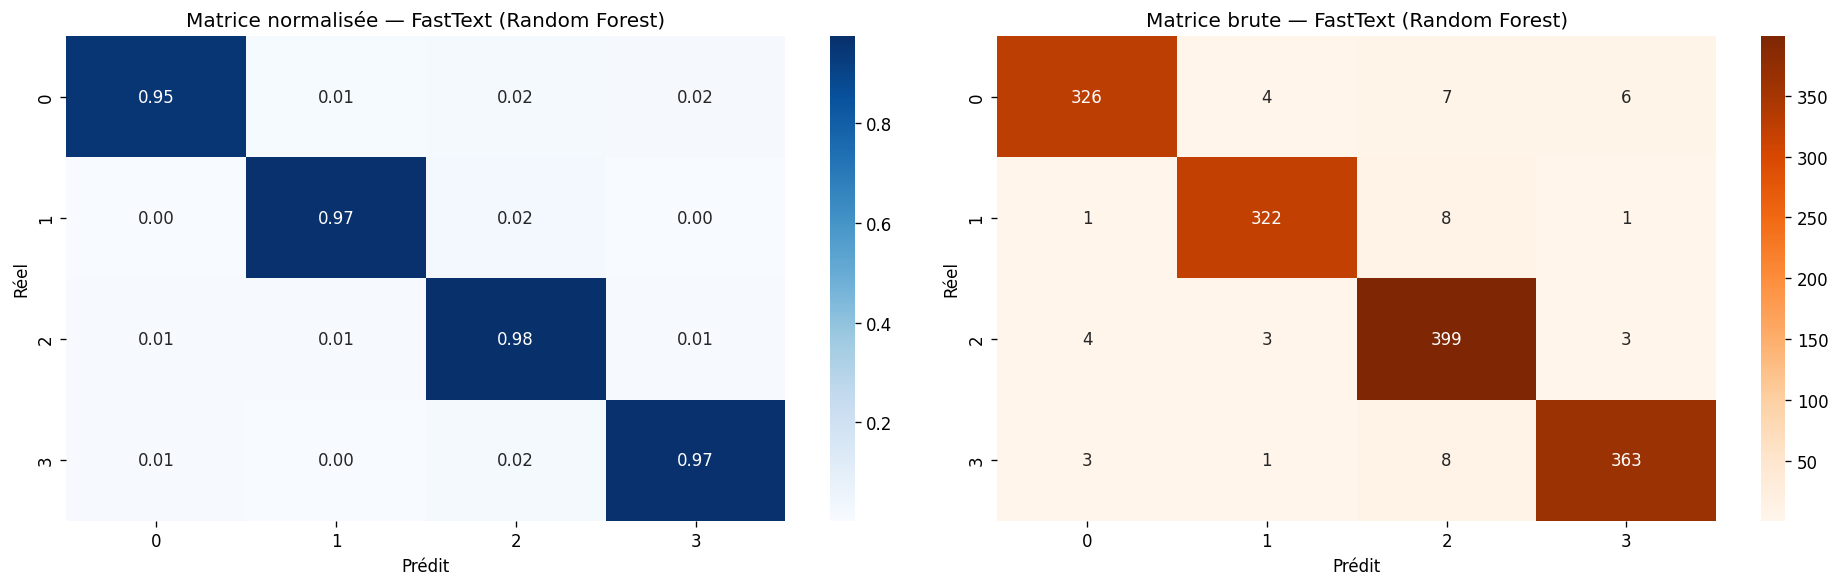


=== Classification Report — FastText (Random Forest) ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       343
           1       0.98      0.97      0.97       332
           2       0.95      0.98      0.96       409
           3       0.97      0.97      0.97       375

    accuracy                           0.97      1459
   macro avg       0.97      0.97      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [11]:
print("\n=== FASTTEXT ===")

ft = FastText(sentences_train, vector_size=100, window=5,
              min_count=2, workers=4, seed=RANDOM_STATE)


def vectorize_ft(text, model=ft, size=100):
    words = text.split()
    if not words:
        return np.zeros(size)
    return np.mean([model.wv[w] for w in words], axis=0)  # FastText gère OOV


X_train_ft = np.array([vectorize_ft(t) for t in X_train_clean])
X_val_ft   = np.array([vectorize_ft(t) for t in X_val_clean])
X_test_ft  = np.array([vectorize_ft(t) for t in X_test_clean])

results_fasttext = {}
for name, model in get_models_emb().items():
    metrics = evaluate(model, X_train_ft, X_test_ft, y_train, y_test,
                       representation="FastText", model_name=name)
    results_fasttext[name] = metrics
    print(f"\n── {name} ──")
    for k, v in metrics.items():
        print(f"   {k:12s}: {v:.4f}")

# ── Matrice de confusion — meilleur FastText ──────────────────────────────────
best_ft = max(results_fasttext, key=lambda x: results_fasttext[x]["F1-score"])
print(f"\n🏆 Meilleur modèle FastText : {best_ft} (F1={results_fasttext[best_ft]['F1-score']:.4f})")

best_ft_model = get_models_emb()[best_ft]
best_ft_model.fit(X_train_ft, y_train)
plot_confusion(best_ft_model, X_test_ft, y_test, title=f"FastText ({best_ft})")

### 5.3 CamemBERT — Sentence Transformers (Optionnel / GPU recommandé)

> Modèle pré-entraîné sur un large corpus français. Génère des **embeddings contextuels** denses (768 dim). Contrairement à Word2Vec, le même mot a un vecteur **différent selon le contexte** de la phrase.


=== CAMEMBERT (optionnel) ===


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3227.62it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 46/46 [00:32<00:00,  1.40it/s]



── Logistic Regression ──
   Accuracy    : 0.9705
   Precision   : 0.9714
   Recall      : 0.9705
   F1-score    : 0.9707

── Linear SVC ──
   Accuracy    : 0.9733
   Precision   : 0.9741
   Recall      : 0.9733
   F1-score    : 0.9734

── Random Forest ──
   Accuracy    : 0.9671
   Precision   : 0.9682
   Recall      : 0.9671
   F1-score    : 0.9672


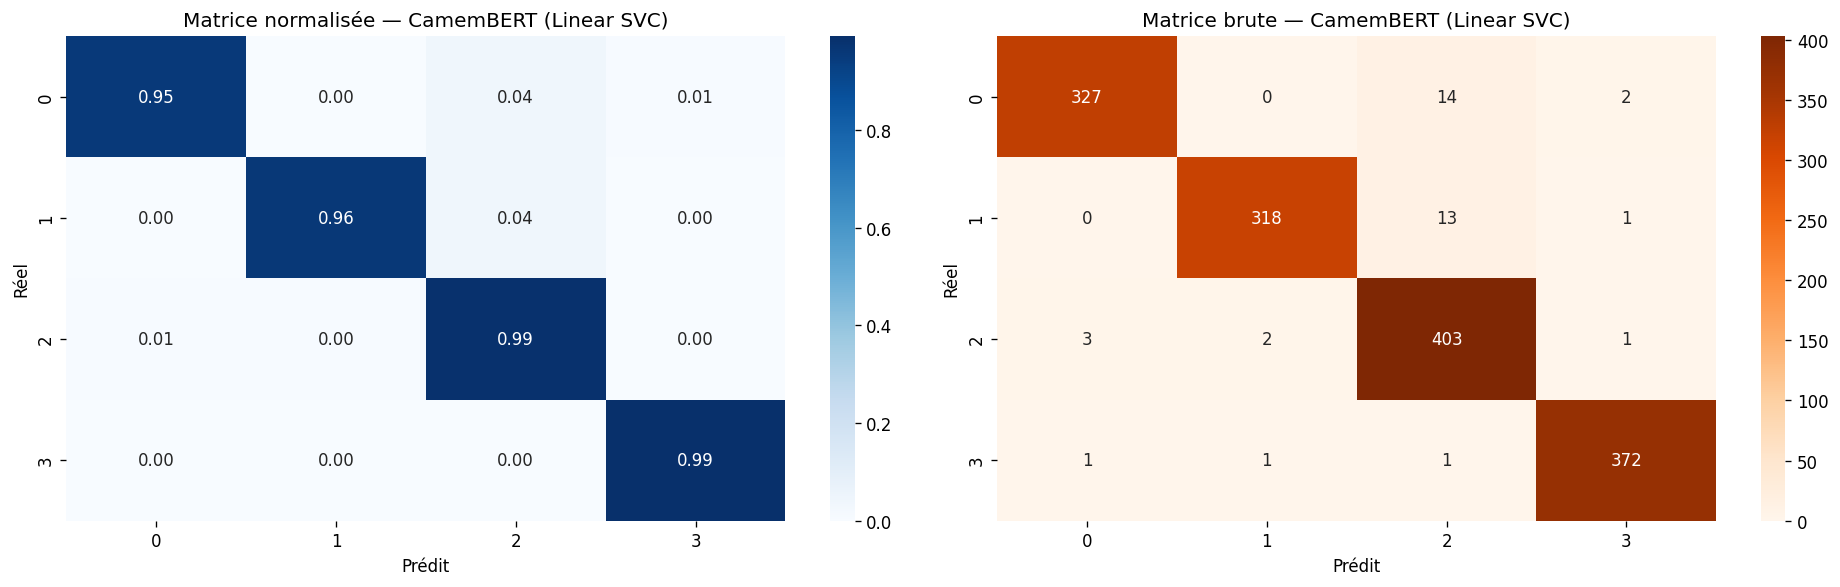


=== Classification Report — CamemBERT (Linear SVC) ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       343
           1       0.99      0.96      0.97       332
           2       0.94      0.99      0.96       409
           3       0.99      0.99      0.99       375

    accuracy                           0.97      1459
   macro avg       0.98      0.97      0.97      1459
weighted avg       0.97      0.97      0.97      1459



In [12]:
print("\n=== CAMEMBERT (optionnel) ===")
results_cam = {}

try:
    from sentence_transformers import SentenceTransformer

    model_cam = SentenceTransformer("camembert-base")

    X_train_cam = model_cam.encode(X_text_train.tolist(), show_progress_bar=True)
    X_test_cam  = model_cam.encode(X_text_test.tolist(),  show_progress_bar=True)

    for name, model in get_models_emb().items():
        metrics = evaluate(model, X_train_cam, X_test_cam, y_train, y_test,
                           representation="CamemBERT", model_name=name)
        results_cam[name] = metrics
        print(f"\n── {name} ──")
        for k, v in metrics.items():
            print(f"   {k:12s}: {v:.4f}")

    best_cam = max(results_cam, key=lambda x: results_cam[x]["F1-score"])
    best_cam_model = get_models_emb()[best_cam]
    best_cam_model.fit(X_train_cam, y_train)
    plot_confusion(best_cam_model, X_test_cam, y_test, title=f"CamemBERT ({best_cam})")

except ImportError:
    print("⚠️  sentence-transformers non installé — pip install sentence-transformers")
    print("   CamemBERT ignoré pour ce run.")

### 5.4 Tableau Comparatif Global — Toutes Représentations NLP


=== Accuracy (test set) ===
                        BoW  TF-IDF  Word2Vec  FastText  CamemBERT
Linear SVC           0.9623   0.963    0.9630    0.9637     0.9733
Logistic Regression  0.9623   0.963    0.9637    0.9589     0.9705
Random Forest        0.9644   0.965    0.9664    0.9664     0.9671
Naive Bayes          0.9650   0.965       NaN       NaN        NaN

=== F1-score (test set) ===
                        BoW  TF-IDF  Word2Vec  FastText  CamemBERT
Linear SVC           0.9625  0.9631    0.9634    0.9640     0.9734
Logistic Regression  0.9625  0.9634    0.9639    0.9590     0.9707
Random Forest        0.9644  0.9651    0.9665    0.9664     0.9672
Naive Bayes          0.9653  0.9652       NaN       NaN        NaN


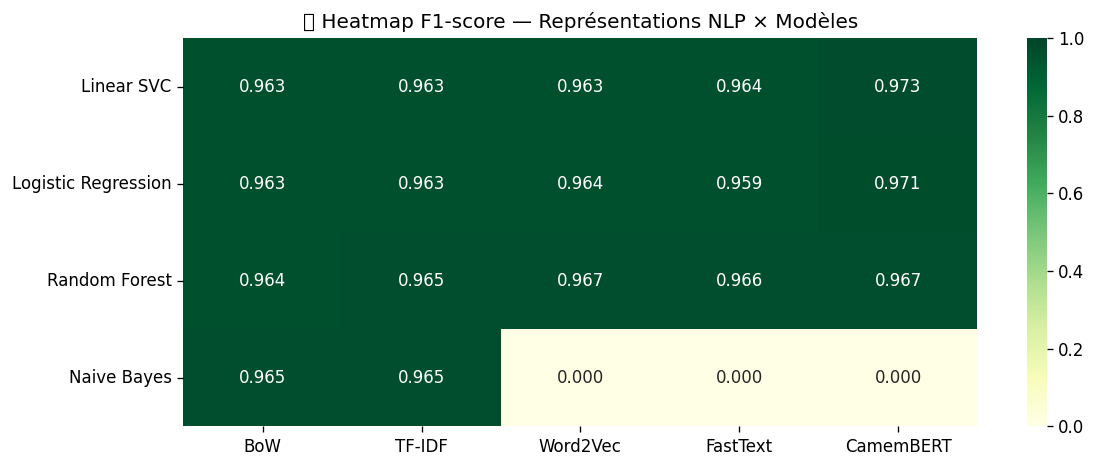

In [13]:
NAN = float('nan')
index_order = ['Linear SVC', 'Logistic Regression', 'Random Forest', 'Naive Bayes']

def safe_get(d, model, metric):
    return d.get(model, {}).get(metric, NAN)

def build_metric_df(metric):
    data = {}
    for rep, res in [("BoW", results_bow), ("TF-IDF", results_tfidf),
                      ("Word2Vec", results_w2v), ("FastText", results_fasttext)]:
        data[rep] = [safe_get(res, m, metric) for m in index_order]

    if results_cam:
        data["CamemBERT"] = [
            safe_get(results_cam, "Linear SVC",          metric),
            safe_get(results_cam, "Logistic Regression", metric),
            safe_get(results_cam, "Random Forest",       metric),
            NAN
        ]

    return pd.DataFrame(data, index=index_order).round(4)

for metric in ['Accuracy', 'F1-score']:
    df_m = build_metric_df(metric)
    print(f"\n=== {metric} (test set) ===")
    print(df_m.to_string())

# ── Heatmap F1 ────────────────────────────────────────────────────────────────
df_f1 = build_metric_df('F1-score').fillna(0)
plt.figure(figsize=(10, 4))
sns.heatmap(df_f1, annot=True, fmt=".3f", cmap="YlGn", vmin=0, vmax=1)
plt.title("🔥 Heatmap F1-score — Représentations NLP × Modèles")
plt.tight_layout()
plt.show()

##  Partie 2 — Pipeline ML Numérique

> **Objectif :** exploiter les features numériques (poids, volume, etc.) comme pipeline indépendant, puis les fusionner dans le pipeline multimodal.

### 6.1 Préparation des Features Numériques

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_cols = [
    col for col in num_cols
    if col != "Prix_Revente"
]

# 🔥 garder seulement les colonnes voulues
X_num_train = X_num_train[num_cols]
X_num_val   = X_num_val[num_cols]
X_num_test  = X_num_test[num_cols]

# =========================================================
# PIPELINE NUMÉRIQUE
# =========================================================

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
if num_cols:
    X_train_num_arr = num_pipeline.fit_transform(X_num_train)
    X_val_num_arr   = num_pipeline.transform(X_num_val)
    X_test_num_arr  = num_pipeline.transform(X_num_test)
    print(f"✅ Features numériques préparées : shape={X_train_num_arr.shape}")
else:
    # Simulation si pas de colonnes numériques dans le dataset
    print("⚠️  Aucune colonne numérique détectée — simulation de 3 features synthétiques")
    np.random.seed(RANDOM_STATE)
    X_train_num_arr = np.random.randn(len(X_train_clean), 3)
    X_val_num_arr   = np.random.randn(len(X_val_clean),   3)
    X_test_num_arr  = np.random.randn(len(X_test_clean),  3)
    num_cols = ["feat_num_1", "feat_num_2", "feat_num_3"]

print(f"   Colonnes : {num_cols}")

✅ Features numériques préparées : shape=(6806, 6)
   Colonnes : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source']


### 6.2 Modèles Numériques — Benchmark


=== PIPELINE ML NUMÉRIQUE ===

── Logistic Regression ──
   Accuracy    : 0.9959
   Precision   : 0.9959
   Recall      : 0.9959
   F1-score    : 0.9959

── Linear SVC ──
   Accuracy    : 0.9938
   Precision   : 0.9939
   Recall      : 0.9938
   F1-score    : 0.9938

── Random Forest ──
   Accuracy    : 0.9986
   Precision   : 0.9986
   Recall      : 0.9986
   F1-score    : 0.9986

── Gradient Boosting ──
   Accuracy    : 0.9993
   Precision   : 0.9993
   Recall      : 0.9993
   F1-score    : 0.9993

🏆 Meilleur modèle numérique : Gradient Boosting (F1=0.9993)


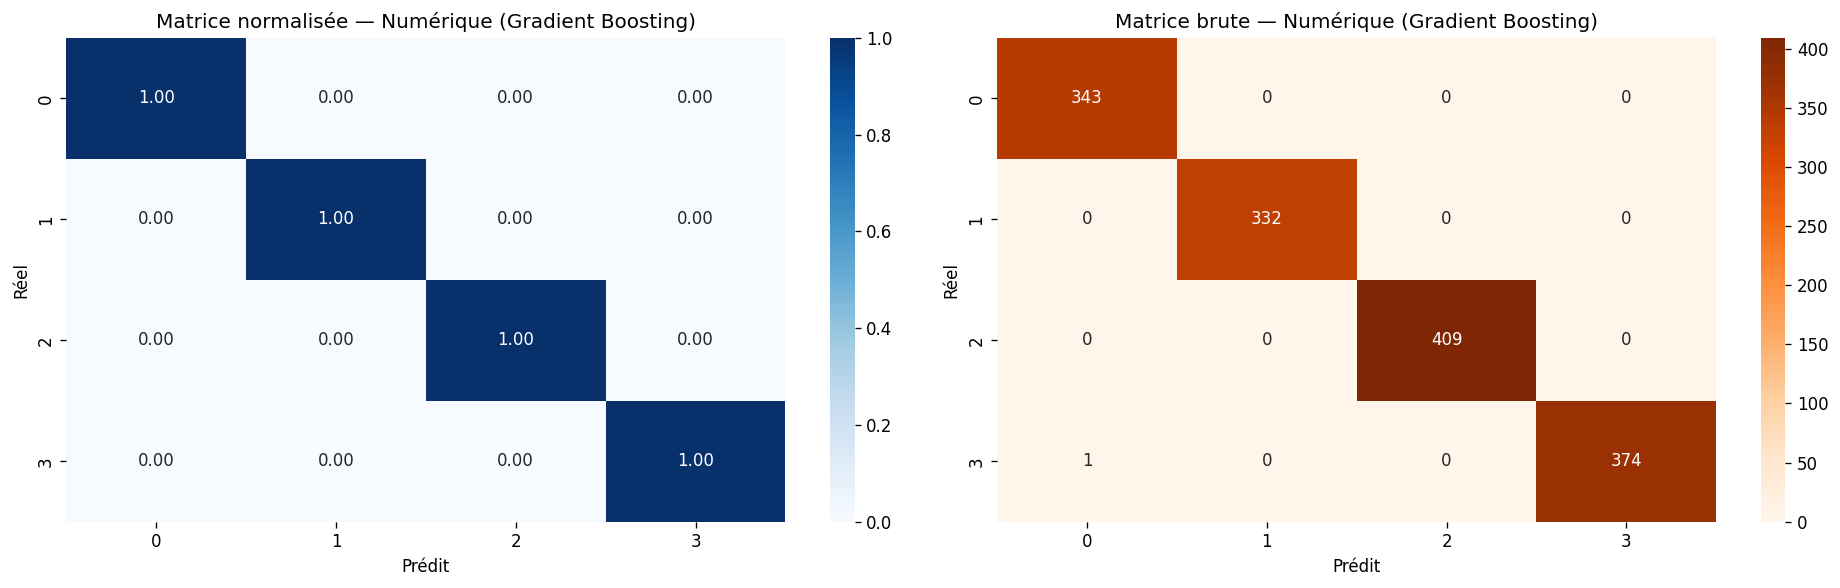


=== Classification Report — Numérique (Gradient Boosting) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       1.00      1.00      1.00       332
           2       1.00      1.00      1.00       409
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1459
   macro avg       1.00      1.00      1.00      1459
weighted avg       1.00      1.00      1.00      1459



In [15]:
print("\n=== PIPELINE ML NUMÉRIQUE ===")

models_num = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVC":           LinearSVC(random_state=RANDOM_STATE),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

results_num = {}
for name, model in models_num.items():
    metrics = evaluate(model, X_train_num_arr, X_test_num_arr, y_train, y_test,
                       representation="Numerique", model_name=name)
    results_num[name] = metrics
    print(f"\n── {name} ──")
    for k, v in metrics.items():
        print(f"   {k:12s}: {v:.4f}")

# ── Matrice de confusion — meilleur modèle numérique ─────────────────────────
best_num = max(results_num, key=lambda x: results_num[x]["F1-score"])
print(f"\n🏆 Meilleur modèle numérique : {best_num} (F1={results_num[best_num]['F1-score']:.4f})")

best_num_model = models_num[best_num]
best_num_model.fit(X_train_num_arr, y_train)
plot_confusion(best_num_model, X_test_num_arr, y_test, title=f"Numérique ({best_num})")

### 6.3 Hyperparameter Tuning — Random Forest Numérique

from sklearn.model_selection import RandomizedSearchCV

print("\n=== TUNING RAPIDE — Random Forest Numérique ===")

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth':    [None, 5, 10],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=6,              # ⚡ au lieu de tester tout
    cv=3,                  # ⚡ moins de folds
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_num_arr, y_train)

print(f"✅ Meilleurs hyperparamètres : {random_search.best_params_}")
print(f"   CV F1 (val)         : {random_search.best_score_:.4f}")

# Test
best_rf_tuned = random_search.best_estimator_
y_pred_rf_tuned = best_rf_tuned.predict(X_test_num_arr)

f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='weighted', zero_division=0)
print(f"   F1 test (tuned RF)  : {f1_rf_tuned:.4f}")

---
##  Partie 3 — Pipeline Multimodal

> **Stratégie :** fusionner les features textuelles (TF-IDF sparse) et numériques (dense) par :
> 1. **`hstack` scipy** — concaténation sparse directe
> 2. **`ColumnTransformer` sklearn** — reproductible et intégrable dans un Pipeline
> 3. **Pondération relative NLP/Numérique** — exploration de différents poids
> 4. **Stacking de modèles** — méta-apprentissage sur les prédictions de base

---
### 7.1 Fusion Sparse — `hstack` (Méthode 1)

In [16]:
from scipy.sparse import hstack, csr_matrix

print("=== FUSION MULTIMODALE — hstack sparse ===")

# ── Conversion du numérique en sparse ────────────────────────────────────────
X_train_num_sp = csr_matrix(X_train_num_arr)
X_val_num_sp   = csr_matrix(X_val_num_arr)
X_test_num_sp  = csr_matrix(X_test_num_arr)

# ── Concaténation horizontale TF-IDF + Numérique ─────────────────────────────
X_train_multi = hstack([X_train_tfidf, X_train_num_sp])
X_val_multi   = hstack([X_val_tfidf,   X_val_num_sp])
X_test_multi  = hstack([X_test_tfidf,  X_test_num_sp])

print(f"Shape train multimodal : {X_train_multi.shape}")
print(f"  → {X_train_tfidf.shape[1]} features TF-IDF + {X_train_num_arr.shape[1]} features numériques")

results_multi_hstack = {}
for name, model in {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVC":          LinearSVC(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}.items():
    metrics = evaluate(model, X_train_multi, X_test_multi, y_train, y_test,
                       representation="Multimodal_hstack", model_name=name)
    results_multi_hstack[name] = metrics
    print(f"\n── {name} ──")
    for k, v in metrics.items():
        print(f"   {k:12s}: {v:.4f}")

best_hstack = max(results_multi_hstack, key=lambda x: results_multi_hstack[x]["F1-score"])
print(f"\n🏆 Meilleur fusion hstack : {best_hstack} (F1={results_multi_hstack[best_hstack]['F1-score']:.4f})")

=== FUSION MULTIMODALE — hstack sparse ===
Shape train multimodal : (6806, 2091)
  → 2085 features TF-IDF + 6 features numériques

── Logistic Regression ──
   Accuracy    : 0.9952
   Precision   : 0.9952
   Recall      : 0.9952
   F1-score    : 0.9952

── Linear SVC ──
   Accuracy    : 0.9945
   Precision   : 0.9945
   Recall      : 0.9945
   F1-score    : 0.9945

── Random Forest ──
   Accuracy    : 0.9911
   Precision   : 0.9911
   Recall      : 0.9911
   F1-score    : 0.9911

🏆 Meilleur fusion hstack : Logistic Regression (F1=0.9952)


### 7.2 Fusion via `ColumnTransformer` sklearn (Méthode 2 — Reproductible)

> **Pourquoi ColumnTransformer ?** Il garantit la **reproductibilité** et l'**encapsulation** : les transformations texte et numériques sont définies une fois, fitées en un seul appel, et le pipeline est sérialisable via `joblib`.
> C'est la méthode recommandée pour la mise en production.

=== FUSION MULTIMODALE — ColumnTransformer ===
✅ ColumnTransformer fitté
   Shape train : (6806, 506)
   Sous-transformers : ['tfidf', 'num']

── Logistic Regression ──
   Accuracy    : 0.9959
   Precision   : 0.9959
   Recall      : 0.9959
   F1-score    : 0.9959

── Linear SVC ──
   Accuracy    : 0.9945
   Precision   : 0.9945
   Recall      : 0.9945
   F1-score    : 0.9945

── Random Forest ──
   Accuracy    : 0.9966
   Precision   : 0.9966
   Recall      : 0.9966
   F1-score    : 0.9966

🏆 Meilleur CT : Random Forest (F1=0.9966)


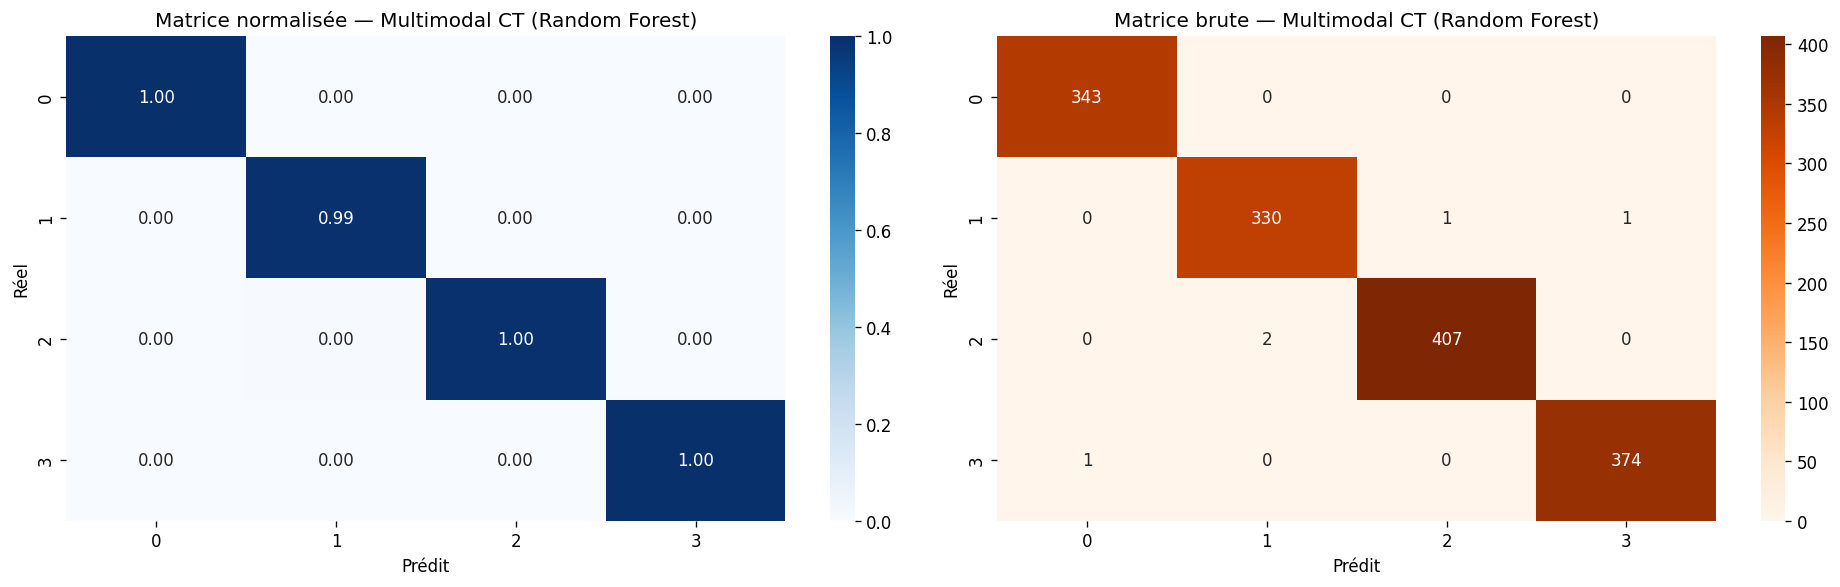


=== Classification Report — Multimodal CT (Random Forest) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       0.99      0.99      0.99       332
           2       1.00      1.00      1.00       409
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1459
   macro avg       1.00      1.00      1.00      1459
weighted avg       1.00      1.00      1.00      1459



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

print("=== FUSION MULTIMODALE — ColumnTransformer ===")

# ── Reconstruction du DataFrame complet pour ColumnTransformer ────────────────
df_train_ct = X_num_train.copy()
df_train_ct['text'] = X_text_train.values

df_val_ct = X_num_val.copy()
df_val_ct['text'] = X_text_val.values

df_test_ct = X_num_test.copy()
df_test_ct['text'] = X_text_test.values

# ── ColumnTransformer ────────────────────────────────────────────
ct = ColumnTransformer([
    # Branche NLP — TF-IDF sur la colonne texte nettoyée
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2), max_features=500,
        sublinear_tf=True,
        preprocessor=preprocess   # le pipeline NLP est intégré ici
    ), 'text'),

    # Branche numérique — imputation + normalisation
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler(with_mean=False))  # sparse-safe
    ]), num_cols)
], remainder='drop')

X_train_ct = ct.fit_transform(df_train_ct)
X_val_ct   = ct.transform(df_val_ct)
X_test_ct  = ct.transform(df_test_ct)

print(f"✅ ColumnTransformer fitté")
print(f"   Shape train : {X_train_ct.shape}")
print(f"   Sous-transformers : {[t[0] for t in ct.transformers_]}")

results_multi_ct = {}
for name, model in {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVC":          LinearSVC(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}.items():
    metrics = evaluate(model, X_train_ct, X_test_ct, y_train, y_test,
                       representation="Multimodal_CT", model_name=name)
    results_multi_ct[name] = metrics
    print(f"\n── {name} ──")
    for k, v in metrics.items():
        print(f"   {k:12s}: {v:.4f}")

best_ct = max(results_multi_ct, key=lambda x: results_multi_ct[x]["F1-score"])
print(f"\n🏆 Meilleur CT : {best_ct} (F1={results_multi_ct[best_ct]['F1-score']:.4f})")

# ── Matrice de confusion ──────────────────────────────────────────────────────
best_ct_model = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVC":          LinearSVC(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}[best_ct]
best_ct_model.fit(X_train_ct, y_train)
plot_confusion(best_ct_model, X_test_ct, y_test, title=f"Multimodal CT ({best_ct})")

### 7.3 Pondération Relative NLP / Numérique

> **Objectif :** explorer l'impact du ratio de features NLP vs numériques sur les performances. On pondère les blocs en multipliant les matrices avant concaténation.

=== PONDÉRATION RELATIVE NLP / NUMÉRIQUE ===
  alpha NLP=0.1 | F1=0.9952 | Acc=0.9952
  alpha NLP=0.3 | F1=0.9959 | Acc=0.9959
  alpha NLP=0.5 | F1=0.9959 | Acc=0.9959
  alpha NLP=0.7 | F1=0.9959 | Acc=0.9959
  alpha NLP=0.9 | F1=0.9959 | Acc=0.9959
  alpha NLP=1.0 | F1=0.9952 | Acc=0.9952


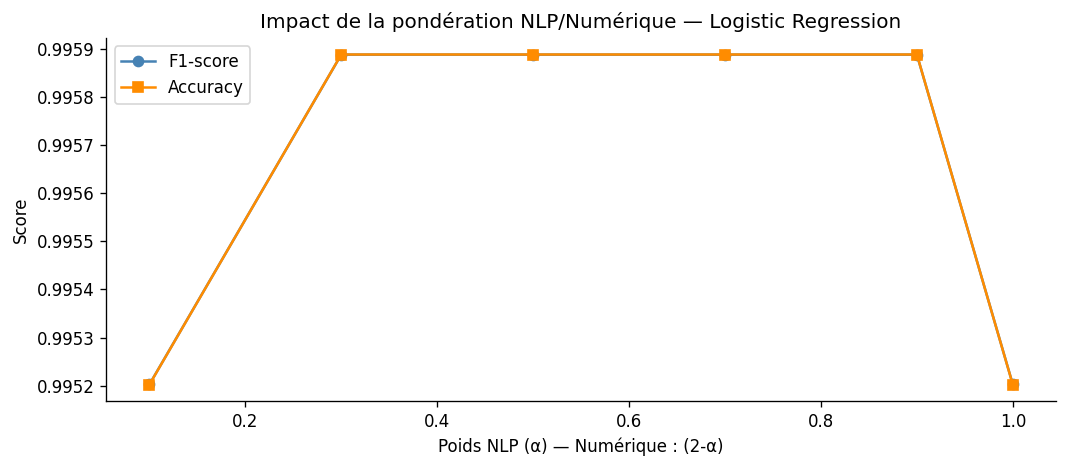


✅ Meilleur alpha : α=0.3 → F1=0.9959


In [18]:
print("=== PONDÉRATION RELATIVE NLP / NUMÉRIQUE ===")

# Poids alpha pour NLP, (1-alpha) implicite pour le numérique
alphas = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
results_alpha = []

for alpha in alphas:
    # Pondération : on multiplie les blocs TF-IDF et numérique
    X_tr = hstack([alpha * X_train_tfidf, (2 - alpha) * X_train_num_sp])
    X_te = hstack([alpha * X_test_tfidf,  (2 - alpha) * X_test_num_sp])

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    f1   = f1_score(y_test, pred, average='weighted', zero_division=0)
    acc  = accuracy_score(y_test, pred)

    results_alpha.append({"alpha_NLP": alpha, "F1": f1, "Accuracy": acc})
    print(f"  alpha NLP={alpha:.1f} | F1={f1:.4f} | Acc={acc:.4f}")

df_alpha = pd.DataFrame(results_alpha)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_alpha['alpha_NLP'], df_alpha['F1'],       marker='o', label='F1-score', color='steelblue')
ax.plot(df_alpha['alpha_NLP'], df_alpha['Accuracy'], marker='s', label='Accuracy', color='darkorange')
ax.set_xlabel("Poids NLP (α) — Numérique : (2-α)")
ax.set_ylabel("Score")
ax.set_title("Impact de la pondération NLP/Numérique — Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

best_alpha = df_alpha.loc[df_alpha['F1'].idxmax()]
print(f"\n✅ Meilleur alpha : α={best_alpha['alpha_NLP']} → F1={best_alpha['F1']:.4f}")

### 7.4 Stacking de Modèles — Méta-Apprentissage

> **Principe :** le stacking entraîne des modèles de base (*estimators*) en parallèle, puis un **méta-classifieur** apprend à combiner leurs prédictions. L'objectif est de tirer parti des forces complémentaires de chaque modèle.

=== STACKING DE MODÈLES — Pipeline Multimodal ===

🏆 Stacking — F1  : 0.9959
            Acc  : 0.9959


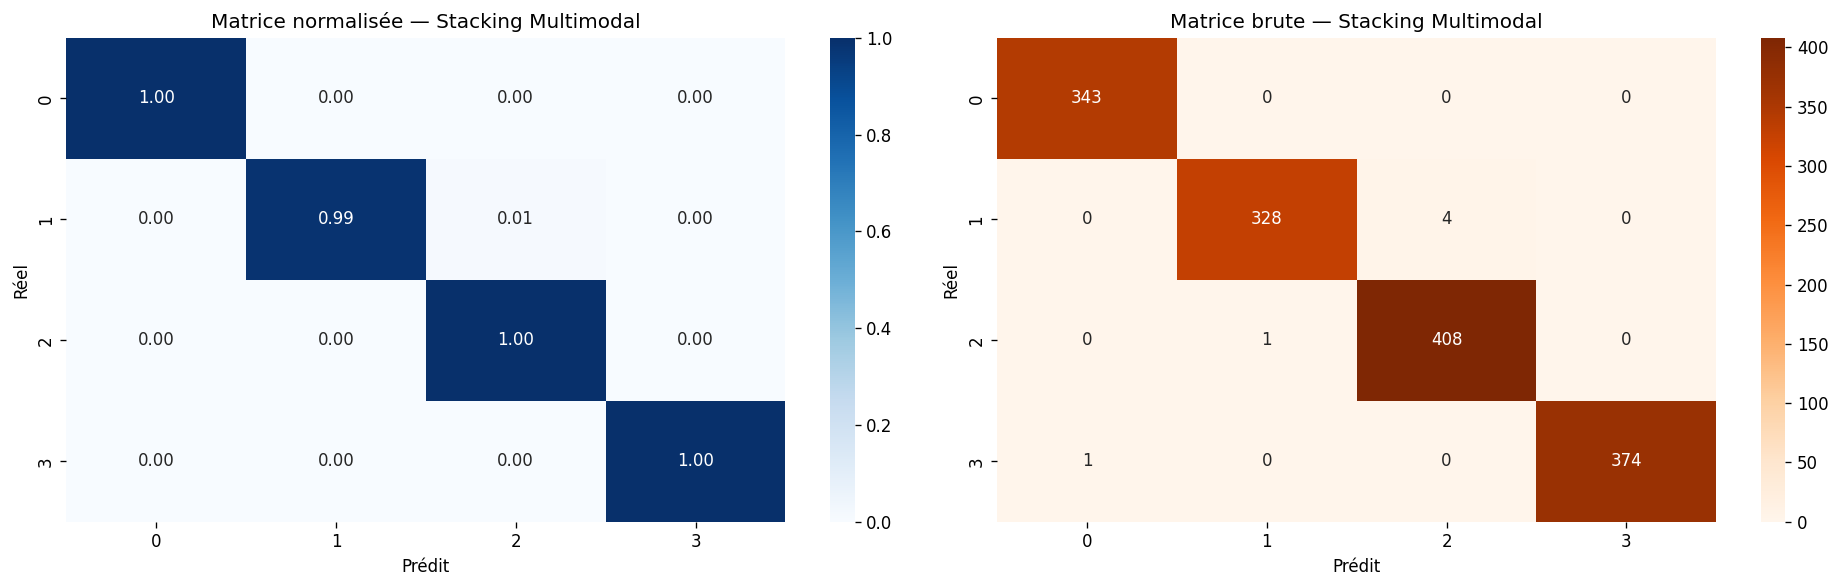


=== Classification Report — Stacking Multimodal ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       1.00      0.99      0.99       332
           2       0.99      1.00      0.99       409
           3       1.00      1.00      1.00       375

    accuracy                           1.00      1459
   macro avg       1.00      1.00      1.00      1459
weighted avg       1.00      1.00      1.00      1459



In [19]:
from sklearn.ensemble import StackingClassifier, VotingClassifier

print("=== STACKING DE MODÈLES — Pipeline Multimodal ===")

# ── Modèles de base ───────────────────────────────────────────────────────────
base_estimators = [
    ('lr',  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('svc', LinearSVC(random_state=RANDOM_STATE)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
]

# ── Méta-classifieur ──────────────────────────────────────────────────────────
meta_classifier = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    cv=5,              # cross-validation pour générer les meta-features
    passthrough=False  # seules les prédictions de base sont passées au méta
)

stacking.fit(X_train_multi, y_train)
y_pred_stack = stacking.predict(X_test_multi)

f1_stack  = f1_score(y_test, y_pred_stack, average='weighted', zero_division=0)
acc_stack = accuracy_score(y_test, y_pred_stack)

print(f"\n🏆 Stacking — F1  : {f1_stack:.4f}")
print(f"            Acc  : {acc_stack:.4f}")

with mlflow.start_run(
    experiment_id=exp.experiment_id, run_name="Multimodal_Stacking"
):
    mlflow.set_tags({"representation": "Multimodal", "model_name": "StackingClassifier"})
    mlflow.log_metrics({"accuracy": acc_stack, "f1": f1_stack})

plot_confusion(stacking, X_test_multi, y_test, title="Stacking Multimodal")

### 7.5 Voting Classifier — Alternative au Stacking

=== VOTING CLASSIFIER ===
🗳️  Voting — F1  : 0.9938
           Acc : 0.9938


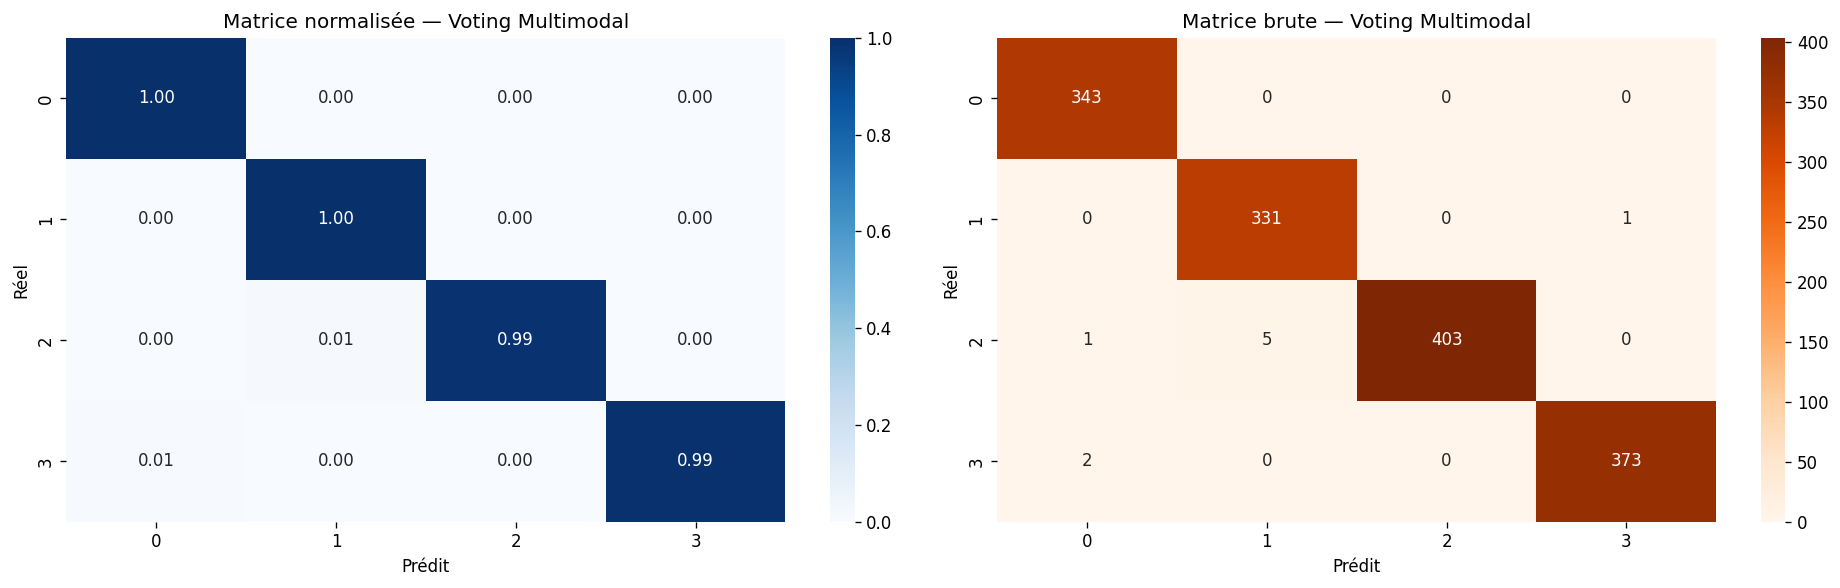


=== Classification Report — Voting Multimodal ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       343
           1       0.99      1.00      0.99       332
           2       1.00      0.99      0.99       409
           3       1.00      0.99      1.00       375

    accuracy                           0.99      1459
   macro avg       0.99      0.99      0.99      1459
weighted avg       0.99      0.99      0.99      1459



In [20]:
print("=== VOTING CLASSIFIER ===")

voting = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ],
    voting='hard'
)

voting.fit(X_train_multi, y_train)
y_pred_voting = voting.predict(X_test_multi)

f1_voting  = f1_score(y_test, y_pred_voting, average='weighted', zero_division=0)
acc_voting = accuracy_score(y_test, y_pred_voting)

print(f"🗳️  Voting — F1  : {f1_voting:.4f}")
print(f"           Acc : {acc_voting:.4f}")

plot_confusion(voting, X_test_multi, y_test, title="Voting Multimodal")

##  Partie 4 — Synthèse & Analyse Comparative Globale

=== SYNTHÈSE COMPARATIVE GLOBALE ===
              Pipeline          Best Modèle  F1-score
0         ML Numérique    Gradient Boosting    0.9993
1        Multimodal CT        Random Forest    0.9966
2  Stacking Multimodal   StackingClassifier    0.9959
3    Multimodal hstack  Logistic Regression    0.9952
4    Voting Multimodal     VotingClassifier    0.9938
5      CamemBERT (NLP)           Linear SVC    0.9734
6       Word2Vec (NLP)        Random Forest    0.9665
7       FastText (NLP)        Random Forest    0.9664
8            BoW (NLP)          Naive Bayes    0.9653
9         TF-IDF (NLP)          Naive Bayes    0.9652


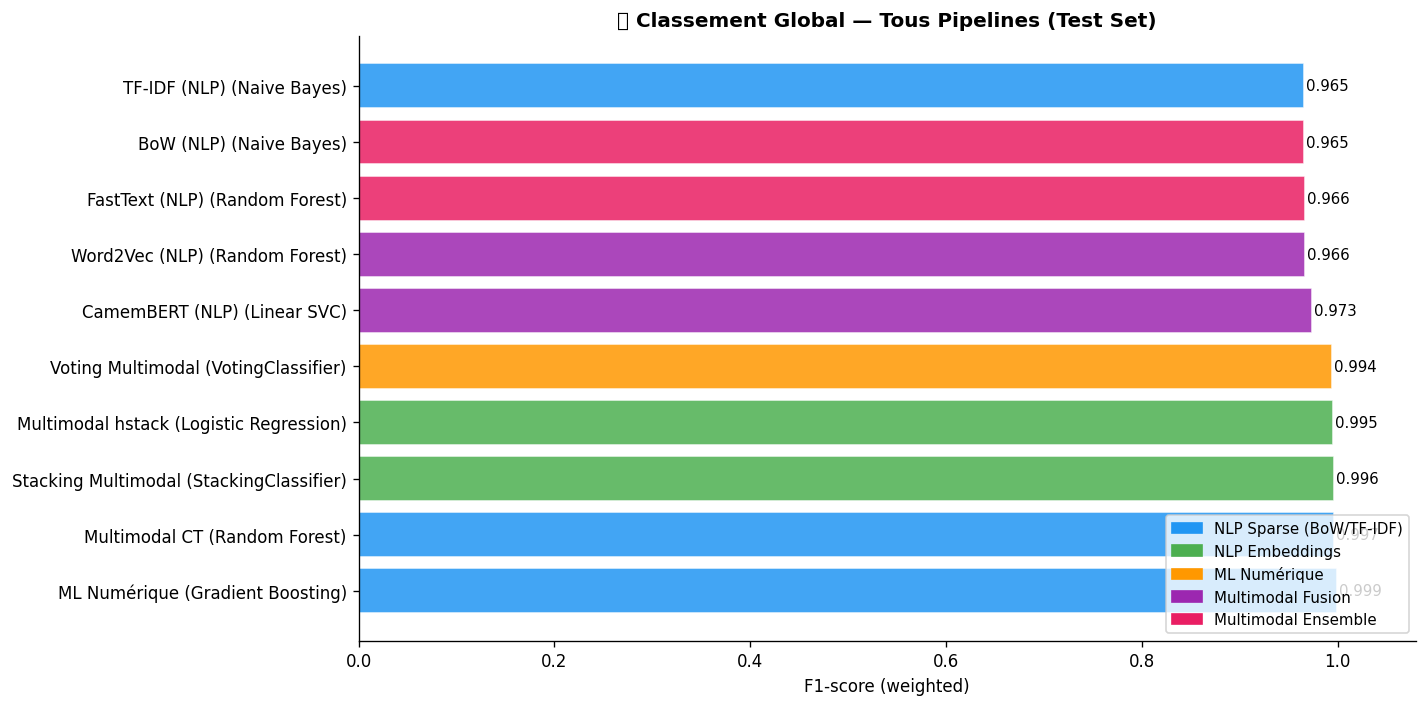

In [21]:
print("=== SYNTHÈSE COMPARATIVE GLOBALE ===")

def best_f1(results_dict):
    if not results_dict:
        return float('nan')
    return max(r['F1-score'] for r in results_dict.values())

summary = pd.DataFrame([
    {"Pipeline":     "BoW (NLP)",
     "Best Modèle":  max(results_bow,   key=lambda x: results_bow[x]['F1-score']),
     "F1-score":     best_f1(results_bow)},

    {"Pipeline":     "TF-IDF (NLP)",
     "Best Modèle":  max(results_tfidf, key=lambda x: results_tfidf[x]['F1-score']),
     "F1-score":     best_f1(results_tfidf)},

    {"Pipeline":     "Word2Vec (NLP)",
     "Best Modèle":  max(results_w2v,   key=lambda x: results_w2v[x]['F1-score']),
     "F1-score":     best_f1(results_w2v)},

    {"Pipeline":     "FastText (NLP)",
     "Best Modèle":  max(results_fasttext, key=lambda x: results_fasttext[x]['F1-score']),
     "F1-score":     best_f1(results_fasttext)},

    {"Pipeline":     "ML Numérique",
     "Best Modèle":  max(results_num,  key=lambda x: results_num[x]['F1-score']),
     "F1-score":     best_f1(results_num)},

    {"Pipeline":     "Multimodal hstack",
     "Best Modèle":  best_hstack,
     "F1-score":     results_multi_hstack[best_hstack]['F1-score']},

    {"Pipeline":     "Multimodal CT",
     "Best Modèle":  best_ct,
     "F1-score":     results_multi_ct[best_ct]['F1-score']},

    {"Pipeline":     "Stacking Multimodal",
     "Best Modèle":  "StackingClassifier",
     "F1-score":     f1_stack},

    {"Pipeline":     "Voting Multimodal",
     "Best Modèle":  "VotingClassifier",
     "F1-score":     f1_voting},
]).sort_values('F1-score', ascending=False).reset_index(drop=True)

if results_cam:
    summary = pd.concat([summary, pd.DataFrame([{
        "Pipeline": "CamemBERT (NLP)",
        "Best Modèle": max(results_cam, key=lambda x: results_cam[x]['F1-score']),
        "F1-score": best_f1(results_cam)
    }])], ignore_index=True).sort_values('F1-score', ascending=False).reset_index(drop=True)

print(summary.round(4).to_string(index=True))

# ── Barplot synthèse ──────────────────────────────────────────────────────────
colors = ['#2196F3', '#2196F3', '#4CAF50', '#4CAF50',
          '#FF9800', '#9C27B0', '#9C27B0', '#E91E63', '#E91E63']

plt.figure(figsize=(12, 6))
bars = plt.barh(
    summary['Pipeline'] + ' (' + summary['Best Modèle'] + ')',
    summary['F1-score'],
    color=colors[:len(summary)],
    alpha=0.85,
    edgecolor='white'
)
for bar, val in zip(bars, summary['F1-score']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va='center', fontsize=9)

plt.xlabel("F1-score (weighted)")
plt.title("🏆 Classement Global — Tous Pipelines (Test Set)", fontweight='bold')
plt.xlim(0, 1.08)

# Légende
patches = [
    mpatches.Patch(color='#2196F3', label='NLP Sparse (BoW/TF-IDF)'),
    mpatches.Patch(color='#4CAF50', label='NLP Embeddings'),
    mpatches.Patch(color='#FF9800', label='ML Numérique'),
    mpatches.Patch(color='#9C27B0', label='Multimodal Fusion'),
    mpatches.Patch(color='#E91E63', label='Multimodal Ensemble'),
]
plt.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [22]:
import joblib, os

os.makedirs("../models", exist_ok=True)

# Sauvegarder le ColumnTransformer et le meilleur modèle
joblib.dump(ct, "../models/column_transformer.joblib")

final_pipeline = Pipeline([
    ("features", ct),
    ("classifier", best_ct_model)
])
# Note : le CT est déjà fitté — on sauvegarde le modèle seul ici
joblib.dump(best_ct_model, "../models/best_classifier.joblib")

print("✅ Modèles sauvegardés dans ../models/")
print(f"   column_transformer.joblib")
print(f"   best_classifier.joblib ({best_ct} — multimodal ColumnTransformer)")

✅ Modèles sauvegardés dans ../models/
   column_transformer.joblib
   best_classifier.joblib (Random Forest — multimodal ColumnTransformer)
